In [2]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import polars as pl
import alphalens as al
import matplotlib.pyplot as plt
from datetime import datetime, time
import calendar

# 配置文件
try:
    import config_local as config
except ImportError:
    import config

# 导入数据接口sdk
import zenidatasdk as zd
client = zd.Client(
    base_url = config.ZENI_URL,
    username = config.ZENI_USERNAME,
    password = config.ZENI_PASSWORD,
)

# 忽视警告信息
warnings.filterwarnings(action = 'ignore')

In [3]:
# 历史回测区间
init_date = '2024-07-01'
start_date = '2024-09-01'
end_date = str(datetime.today().date())
index_symbol = rf"000852.XSHG"

# rf"000300.XSHG",  # 沪深300
# rf"000905.XSHG",  # 中证500
# rf"000852.XSHG",  # 中证1000
# rf"000016.XSHG",  # 上证50
# rf"399006.XSHE",  # 创业板

In [4]:
# 获取指数成分股数据据
index_weights_df = client.get_index_constituents_df(
    index_symbol = index_symbol,
    start_date = start_date,
    end_date = end_date
)
index_weights_df = index_weights_df.rename( columns = {"date": "datetime"} )
symbols = index_weights_df["symbol"].unique().tolist()
index_weights_df

,datetime,index_symbol,update_date,symbol,weight,display_name
0,2024-09-02,000852.XSHG,2024-08-30,000012.XSHE,0.145,南玻A
1,2024-09-02,000852.XSHG,2024-08-30,000016.XSHE,0.064,深康佳A
2,2024-09-02,000852.XSHG,2024-08-30,000019.XSHE,0.041,深粮控股
3,2024-09-02,000852.XSHG,2024-08-30,000025.XSHE,0.057,特力A
4,2024-09-02,000852.XSHG,2024-08-30,000028.XSHE,0.103,国药一致
...,...,...,...,...,...,...
391995,2026-04-20,000852.XSHG,2026-03-31,688776.XSHG,0.055,国光电气
391996,2026-04-20,000852.XSHG,2026-03-31,688779.XSHG,0.143,五矿新能
391997,2026-04-20,000852.XSHG,2026-03-31,688789.XSHG,0.084,宏华数科
391998,2026-04-20,000852.XSHG,2026-03-31,688798.XSHG,0.073,艾为电子


In [5]:
tmp_Dataset_path = rf"D:\tmp_Dataset"
minute_bar_Dataset_path = os.path.join(tmp_Dataset_path, "minute_bar")  # 分钟数据本地路径
os.makedirs(minute_bar_Dataset_path, exist_ok=True)

index_weights_path = os.path.join(minute_bar_Dataset_path, index_symbol)  # 指数成分股
os.makedirs(index_weights_path, exist_ok=True)

In [6]:
def generate_monthly_ranges_dict(start_date, end_date):
    """生成按月切割的日期区间字典，格式为 {YYMM: (月初, 月末)}"""
    start = datetime.strptime(start_date, '%Y-%m-%d').date()
    end = datetime.strptime(end_date, '%Y-%m-%d').date()

    date_dict = {}
    current = start

    while True:
        month_start = current.replace(day=1)
        _, last_day = calendar.monthrange(current.year, current.month)
        month_end = current.replace(day=last_day)

        if month_end > end:  # 不足一个月舍弃
            break

        # 键格式：YYMM（如 2603 表示 2026年03月）
        key = f"{str(current.year)[-2:]}{current.month:02d}"
        date_dict[key] = (month_start.strftime('%Y-%m-%d'), month_end.strftime('%Y-%m-%d'))

        # 移到下个月
        if current.month == 12:
            current = current.replace(year=current.year + 1, month=1, day=1)
        else:
            current = current.replace(month=current.month + 1, day=1)

    return date_dict


date_tuple_list = generate_monthly_ranges_dict(init_date, end_date)
date_tuple_list

{'2407': ('2024-07-01', '2024-07-31'),
 '2408': ('2024-08-01', '2024-08-31'),
 '2409': ('2024-09-01', '2024-09-30'),
 '2410': ('2024-10-01', '2024-10-31'),
 '2411': ('2024-11-01', '2024-11-30'),
 '2412': ('2024-12-01', '2024-12-31'),
 '2501': ('2025-01-01', '2025-01-31'),
 '2502': ('2025-02-01', '2025-02-28'),
 '2503': ('2025-03-01', '2025-03-31'),
 '2504': ('2025-04-01', '2025-04-30'),
 '2505': ('2025-05-01', '2025-05-31'),
 '2506': ('2025-06-01', '2025-06-30'),
 '2507': ('2025-07-01', '2025-07-31'),
 '2508': ('2025-08-01', '2025-08-31'),
 '2509': ('2025-09-01', '2025-09-30'),
 '2510': ('2025-10-01', '2025-10-31'),
 '2511': ('2025-11-01', '2025-11-30'),
 '2512': ('2025-12-01', '2025-12-31'),
 '2601': ('2026-01-01', '2026-01-31'),
 '2602': ('2026-02-01', '2026-02-28'),
 '2603': ('2026-03-01', '2026-03-31')}

In [8]:
def tmp_filter(dataframe):
    # 1. 临时转换为 datetime 用于过滤
    # 2. 过滤后删除临时列，保留原始字符串
    return (
        dataframe
        .filter(
            (pl.col("datetime").dt.time() <= pl.time(10, 0, 0)) |
            (pl.col("datetime").dt.time() == pl.time(15, 0, 0))
        )
    )

tmp_filter = None

In [9]:
big_minute_bar_dict = {}

from tqdm import tqdm
for month, start_end_tuple in tqdm(
        date_tuple_list.items(), desc = "获取每月分钟数据"
):
    minute_bar_monthly_path = os.path.join(index_weights_path, rf"{month}.parquet")
    if os.path.exists(minute_bar_monthly_path):
        bars_1m_pl_tmp = pl.read_parquet(minute_bar_monthly_path)
    else:
        bars_1m_df_tmp = client.get_kline_df(
            symbol = symbols,
            start_date = start_end_tuple[0],
            end_date = start_end_tuple[1],
            frequency = "1m",
            adjust_type = "post",
            market = "cn_stock",
        )
        bars_1m_pl_tmp = pl.from_pandas(bars_1m_df_tmp)
        bars_1m_pl_tmp.write_parquet(minute_bar_monthly_path, compression = 'snappy')

    # 删除部分数据，减少内存负担 tmp_filter
    if tmp_filter:
        big_minute_bar_dict[month] = tmp_filter(bars_1m_pl_tmp)
    else:
        big_minute_bar_dict[month] = bars_1m_pl_tmp
    import gc; gc.collect()


# 分钟数据长表格 bars_1m_df
bars_1m_pl = pl.concat(list(big_minute_bar_dict.values()))
bars_1m_pl.glimpse()
bars_1m_pl.head()

获取每月分钟数据: 100%|██████████| 21/21 [00:04<00:00,  4.64it/s]

Rows: 231373200
Columns: 8
$ open              <f64> 197.26, 197.78, 197.78, 199.33, 198.81, 198.81, 199.33, 198.81, 198.3, 197.78
$ high              <f64> 198.3, 199.84, 199.84, 199.84, 198.81, 199.33, 199.33, 198.81, 198.81, 197.78
$ low               <f64> 195.2, 197.78, 197.78, 198.81, 198.3, 198.3, 198.81, 198.3, 197.78, 197.78
$ close             <f64> 198.3, 197.78, 199.33, 199.33, 198.3, 198.81, 198.81, 198.3, 197.78, 197.78
$ volume            <f64> 30374.06, 15674.04, 11131.01, 3532.18, 9053.14, 7914.48, 4055.03, 4465.57, 6173.57, 6527.95
$ symbol            <str> '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE', '000006.XSHE'
$ amount            <f64> 5974874.0, 3108409.0, 2217115.0, 705240.0, 1798021.0, 1574042.0, 806109.0, 887925.0, 1223348.0, 1291093.0
$ datetime <datetime[ns]> 2024-07-01 09:31:00, 2024-07-01 09:32:00, 2024-07-01 09:33:00, 2024-07-01 09:34:00, 2024-07-01 09:35:00, 2024-0

open,high,low,close,volume,symbol,amount,datetime
f64,f64,f64,f64,f64,str,f64,datetime[ns]
197.26,198.3,195.2,198.3,30374.06,"""000006.XSHE""",5.974874e6,2024-07-01 09:31:00
197.78,199.84,197.78,197.78,15674.04,"""000006.XSHE""",3.108409e6,2024-07-01 09:32:00
197.78,199.84,197.78,199.33,11131.01,"""000006.XSHE""",2.217115e6,2024-07-01 09:33:00
199.33,199.84,198.81,199.33,3532.18,"""000006.XSHE""",705240.0,2024-07-01 09:34:00
198.81,198.81,198.3,198.3,9053.14,"""000006.XSHE""",1.798021e6,2024-07-01 09:35:00


In [10]:
# 本因子是混频算法，需要从高频提取信息用于日频交易
prices_pl = bars_1m_pl.rename(mapping = {"datetime": "datetime_min"})
prices_pl = prices_pl.with_columns(
    pl.col("datetime_min").dt.truncate("1d")    # 截断到天
    .alias("datetime")  # 命名为 datetime。alias 意思是"别名"、"假名"
                        # 在命令 .withcolumns 中表达式若带有 alias 则生成新的列
                        # 否则覆盖原有的列
)

# 多资产价格数据(开盘价买入)
prices_pl = prices_pl.filter( pl.col("datetime") >= pl.lit(datetime.strptime(start_date, "%Y-%m-%d")) )
prices_pl = prices_pl.group_by(['datetime', 'symbol']).agg(
    pl.col('open').first()
) # 取出每一天的第一个价格作为日开盘价
# 注意，Polars 没有 Index 概念，结果始终是 DataFrame，列是扁平的

prices = prices_pl.pivot(index = "datetime", columns = "symbol", values = "open").sort("datetime")
prices = prices.to_pandas().set_index("datetime") # 转化回可被 aplhalens 计算的 pd,dataframe
prices.T.head().T.head()

,688076.XSHG,603815.XSHG,601588.XSHG,002745.XSHE,603100.XSHG
datetime,,,,,
2024-09-02,57.59,5.50,1.72,17.51,26.22
2024-09-03,58.80,5.50,1.71,16.74,24.96
2024-09-04,59.03,5.58,1.72,16.83,25.12
2024-09-05,60.05,5.86,1.72,16.88,26.75
2024-09-06,61.66,5.79,1.76,16.97,26.47


In [11]:
def f_1228_polars(bars: pd.DataFrame, f_name: str = 'Average_relative_price_position', cal_range = 1, roll_days: int = 20) -> pd.DataFrame:
    """
    factor_intro: 衡量股票在价格相对高位停留的时间长短
    category: 高频因子
    category_intro: 收益率分布类
    subcategory:
    subcategory_intro:
    min_period: 20d
    source: 朱剑涛, 2020, 基于时间维度度量的日内买卖压力, 东方证券
    author: 因子团队

    说明：使用每日 K 线的典型价格 (开盘 + 收盘 + 最高 + 最低) / 4 计算日内时间加权平均价格（TWAP），
    并在过去 cal_range 个交易日内按交易时长加权平均，再对过去 roll_days 个交易日做滚动平滑，
    作为原始因子值。根据以上计算过程，判断因子方向为正向。

    因子逻辑：股票在价格相对高位停留的时间越长，表明买方压力越大，未来收益越高；
    通过度量价格在相对高位停留的时间长短，捕捉买方压力较大的股票。

    Parameters
    ----------
    bars: pd.DataFrame
        分钟频 bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close']
    f_name: str
        因子名称，默认为 'Average_relative_price_position'
    cal_range: int
        时间窗口天数，默认为 1。研报原文分别基于1日、5日、20日三个时间窗口
        滚动计算指标，本实现采用过去 cal_range 日滚动加权平均替代。
    roll_days: int
        滚动平滑天数，默认为 20。研报原文做20个交易日的平滑得到最终因子，
        本实现采用过去 roll_days 日滚动均值替代。

    Returns
    -------
    factors: pd.DataFrame
        日频 factors
        ['datetime', 'symbol', 'factor_name', 'factor_value']
    """


    bars = bars.rename(mapping = {"datetime": "datetime_min"})
    bars = bars.with_columns(
        pl.col('datetime_min').dt.date().alias('datetime')
    )

    bars = bars.with_columns([
        ((pl.col('open') + pl.col('close') + pl.col('high') + pl.col('low')) / 4).alias('typical_price')
    ])

    bars = (
        bars.group_by(['symbol', 'datetime'])
        .agg([
            pl.col('typical_price').mean().alias('twap'),
            pl.col("high").max().alias('high'),
            pl.col('low').min().alias('low'),
            pl.count().alias("num_min_K"),
        ]).sort(['symbol', 'datetime'])
    )

    twap_d = rf'twap_{cal_range}d'
    twap_d_d = rf'twap_{cal_range}d_{roll_days}d'

    bars = bars.with_columns(
        (
            (pl.col('twap') * pl.col('num_min_K'))
            .rolling_sum(window_size = cal_range)
            .over('symbol') /
            pl.col('num_min_K')
            .rolling_sum(window_size = cal_range)
            .over('symbol')
        ).alias(twap_d)
    )

    bars = bars.with_columns(
        pl.col(twap_d)
        .rolling_mean(window_size = roll_days)
        .over('symbol')
        .alias('factor_value')
    )

    # 转化为可用于 alphalens 计算的 pd.dataframe
    bars = bars.select([
        "symbol",
        "datetime",
        "factor_value",
        pl.lit(twap_d_d).alias("factor_name"),
    ])
    return bars.to_pandas()

In [18]:
factors_df = f_1228_polars(
    bars = bars_1m_pl,
    f_name = 'Average_relative_price_position',
    cal_range = 1,
    roll_days = 20)
factors_df

,symbol,datetime,factor_value,factor_name
0,000006.XSHE,2024-07-01,NaN,twap_1d_20d
1,000006.XSHE,2024-07-02,NaN,twap_1d_20d
2,000006.XSHE,2024-07-03,NaN,twap_1d_20d
3,000006.XSHE,2024-07-04,NaN,twap_1d_20d
4,000006.XSHE,2024-07-05,NaN,twap_1d_20d
...,...,...,...,...
964050,688800.XSHG,2026-03-25,171.930072,twap_1d_20d
964051,688800.XSHG,2026-03-26,170.974616,twap_1d_20d
964052,688800.XSHG,2026-03-27,169.285721,twap_1d_20d
964053,688800.XSHG,2026-03-30,167.874886,twap_1d_20d


In [19]:
# 因子值 shift 1 转换成实际使用时间 (T+1)
factors_df['factor_value'] = factors_df.groupby('symbol')['factor_value'].transform(lambda x: x.shift(1))

# 与指数的交易日历、历史成分股数据对齐
factors_df = pd.merge(index_weights_df[["datetime", "symbol"]], factors_df, how = "left", on = ["datetime", "symbol"])

# 转换成[datetime, symbol]双重索引的factor_table
factors = factors_df.pivot_table(index = ["datetime", "symbol"], columns = "factor_name", values = "factor_value")
factors.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 379000 entries, (Timestamp('2024-09-02 00:00:00'), '000012.XSHE') to (Timestamp('2026-03-31 00:00:00'), '688800.XSHG')
Data columns (total 1 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   twap_1d_20d  379000 non-null  float64
dtypes: float64(1)
memory usage: 4.4+ MB


In [20]:
# 调用alphalens进行数据清洗
factor_data = al.utils.get_clean_factor_and_forward_returns(
    factor=factors,
    prices=prices,
    periods=(1, 5, 20),
    bins=None,
    quantiles=7,
    groupby=None,
    groupby_labels=None,
    binning_by_group=False,
    filter_zscore=20,
    max_loss=0.25,
    zero_aware=False,
    cumulative_returns=True
)
factor_data

Dropped 5.3% entries from factor data: 5.3% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 25.0%, not exceeded: OK!


1D        5D       20D      factor  \
date       asset                                                   
2024-09-02 000012.XSHE -0.019724 -0.039392  0.155494  183.040948   
           000016.XSHE -0.068485 -0.097391  0.299733   63.904119   
           000019.XSHE  0.000000  0.014977  0.147901   37.277320   
           000025.XSHE -0.005779 -0.007355  0.247964   37.810695   
           000028.XSHE -0.037318 -0.021224  0.229883  154.622641   
...                          ...       ...       ...         ...   
2026-03-03 688776.XSHG -0.060077  0.014271 -0.229590  154.687169   
           688779.XSHG -0.080000 -0.026667 -0.086667   10.760254   
           688789.XSHG -0.022491 -0.091102 -0.206820  175.898916   
           688798.XSHG -0.086003 -0.065981 -0.151620  111.194491   
           688800.XSHG -0.076401 -0.090248 -0.161476  163.398551   

                        factor_quantile  
date       asset                         
2024-09-02 000012.XSHE                7  
           000016.XSHE                5  
           000019.XSHE                4  
           000025.XSHE                4  
           000028.XSHE                7  
...                                 ...  
2026-03-03 688776.XSHG                6  
           688779.XSHG                1  
           688789.XSHG                6  
           688798.XSHG                5  
           688800.XSHG                6  

[359000 rows x 5 columns]

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,2.377118,25.232053,12.476587,5.216578,51337,14.3
2,14.135936,39.696069,25.473556,4.687101,51337,14.3
3,22.610555,59.963019,38.409031,6.875135,51337,14.3
4,32.133695,86.550756,56.223399,10.262683,50978,14.2
5,45.161892,126.826093,80.381181,15.161180,51337,14.3
6,63.352304,192.390766,117.322241,22.731118,51337,14.3
7,100.587492,63739.450554,763.402539,3996.699442,51337,14.3


Returns Analysis


,1D,5D,20D
Ann. alpha,0.150,0.160,0.103
beta,0.050,0.053,0.152
Mean Period Wise Return Top Quantile (bps),-1.865,-1.958,-1.592
Mean Period Wise Return Bottom Quantile (bps),0.024,-0.514,-0.571
Mean Period Wise Spread (bps),-1.889,-1.424,-0.975


<Figure size 640x480 with 0 Axes>

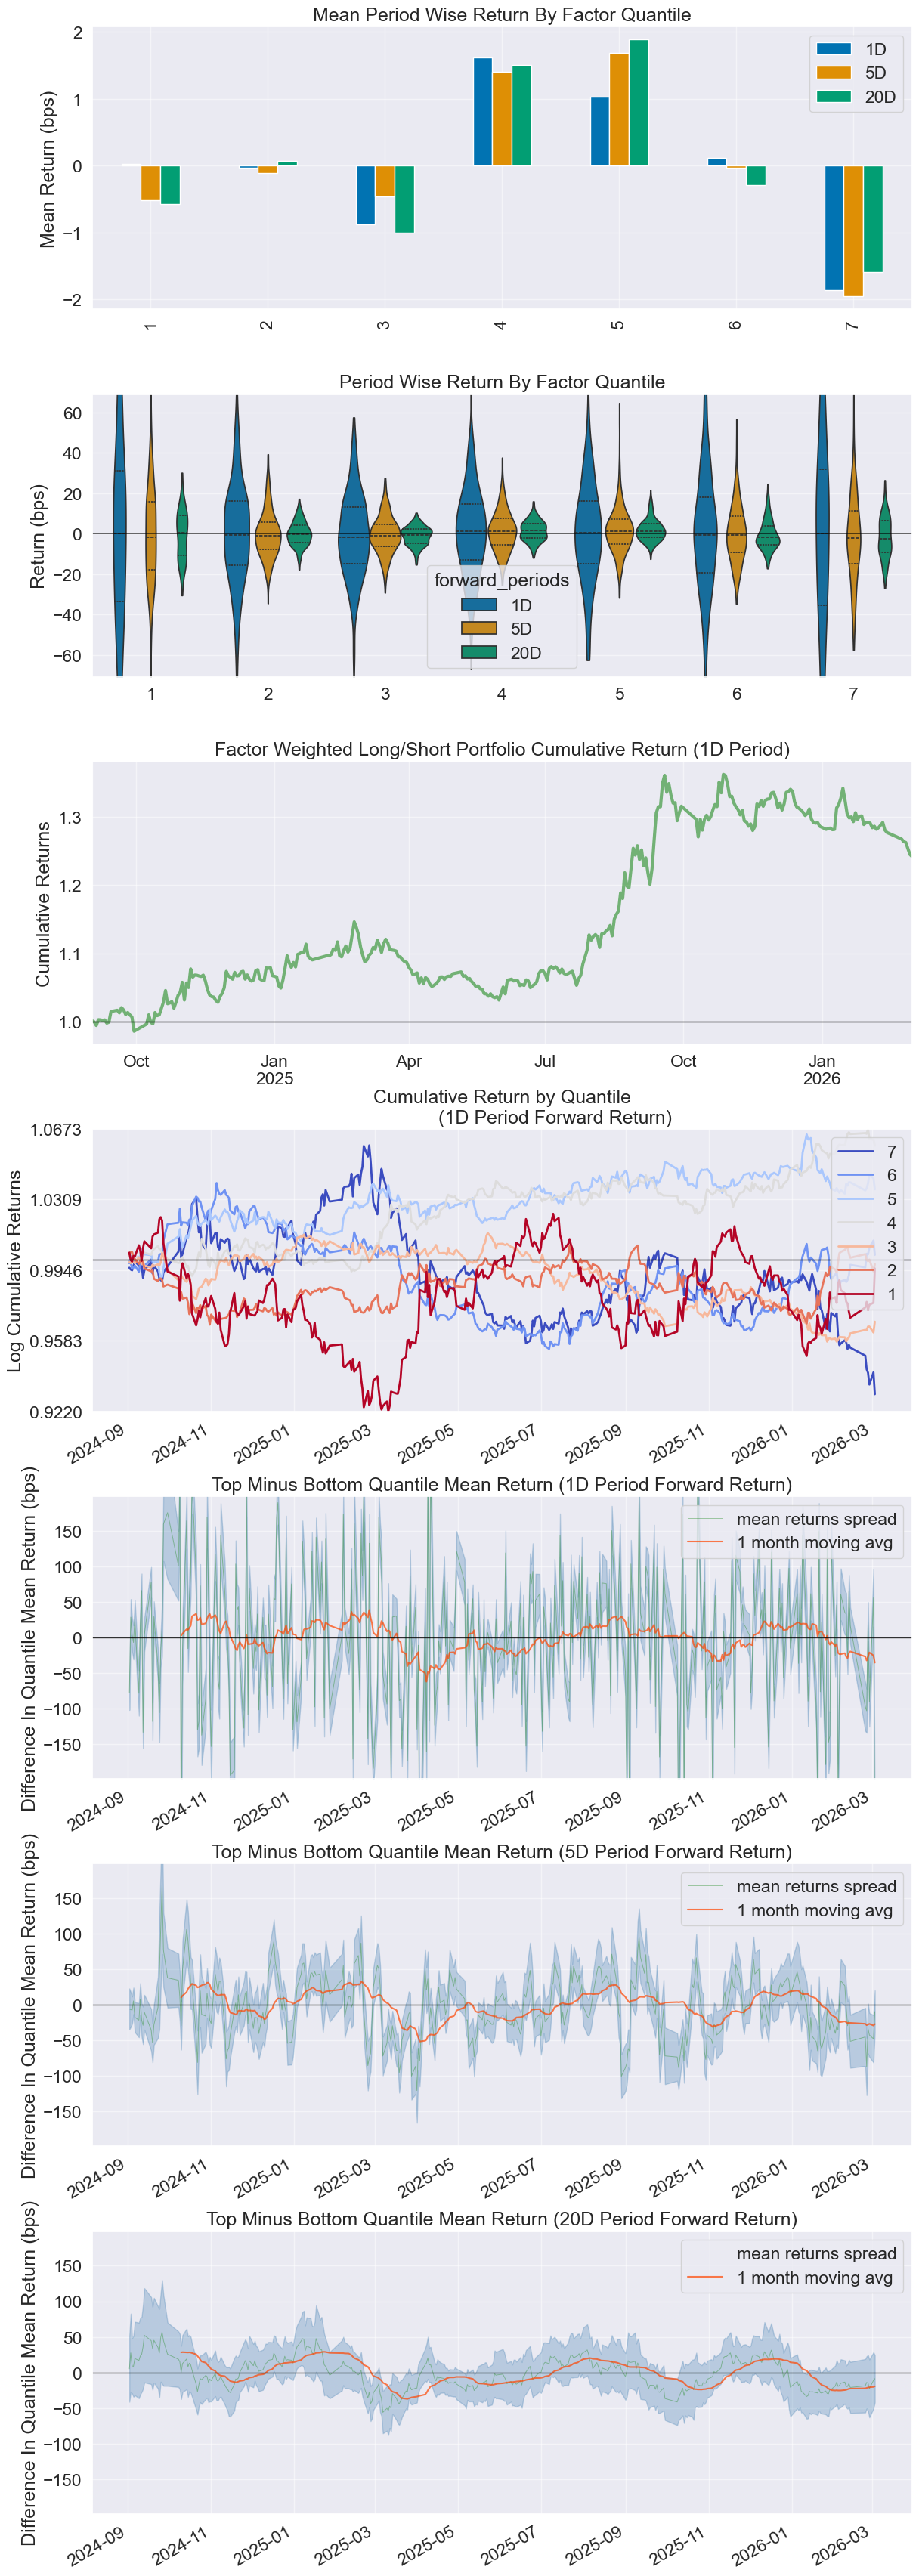

Information Analysis


,1D,5D,20D
IC Mean,-0.010,-0.013,-0.024
IC Std.,0.117,0.115,0.118
Risk-Adjusted IC,-0.082,-0.116,-0.199
t-stat(IC),-1.558,-2.192,-3.766
p-value(IC),0.120,0.029,0.000
IC Skew,-0.104,-0.233,-0.078
IC Kurtosis,-0.631,-0.842,-0.908


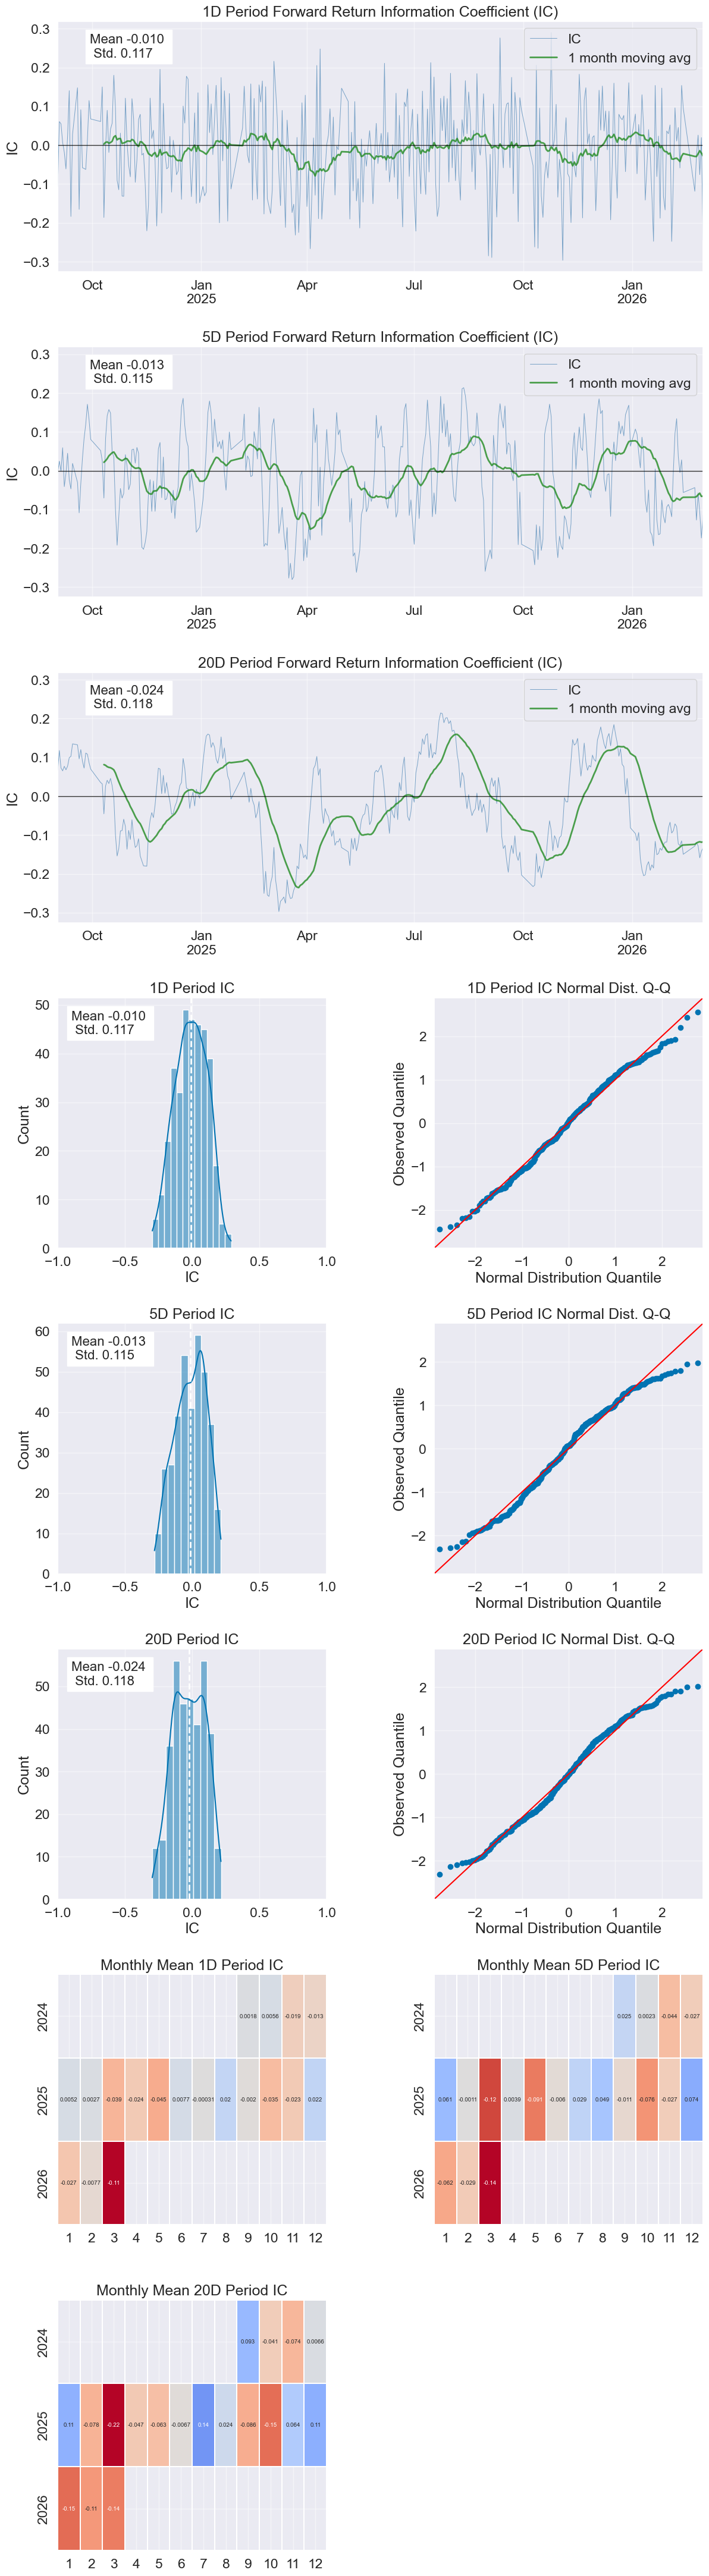

Turnover Analysis


,1D,5D,20D
Quantile 1 Mean Turnover,0.005,0.021,0.069
Quantile 2 Mean Turnover,0.010,0.042,0.139
Quantile 3 Mean Turnover,0.012,0.051,0.168
Quantile 4 Mean Turnover,0.014,0.059,0.192
Quantile 5 Mean Turnover,0.014,0.061,0.198
Quantile 6 Mean Turnover,0.012,0.051,0.167
Quantile 7 Mean Turnover,0.005,0.024,0.082


,1D,5D,20D
Mean Factor Rank Autocorrelation,1.0,1.0,0.995


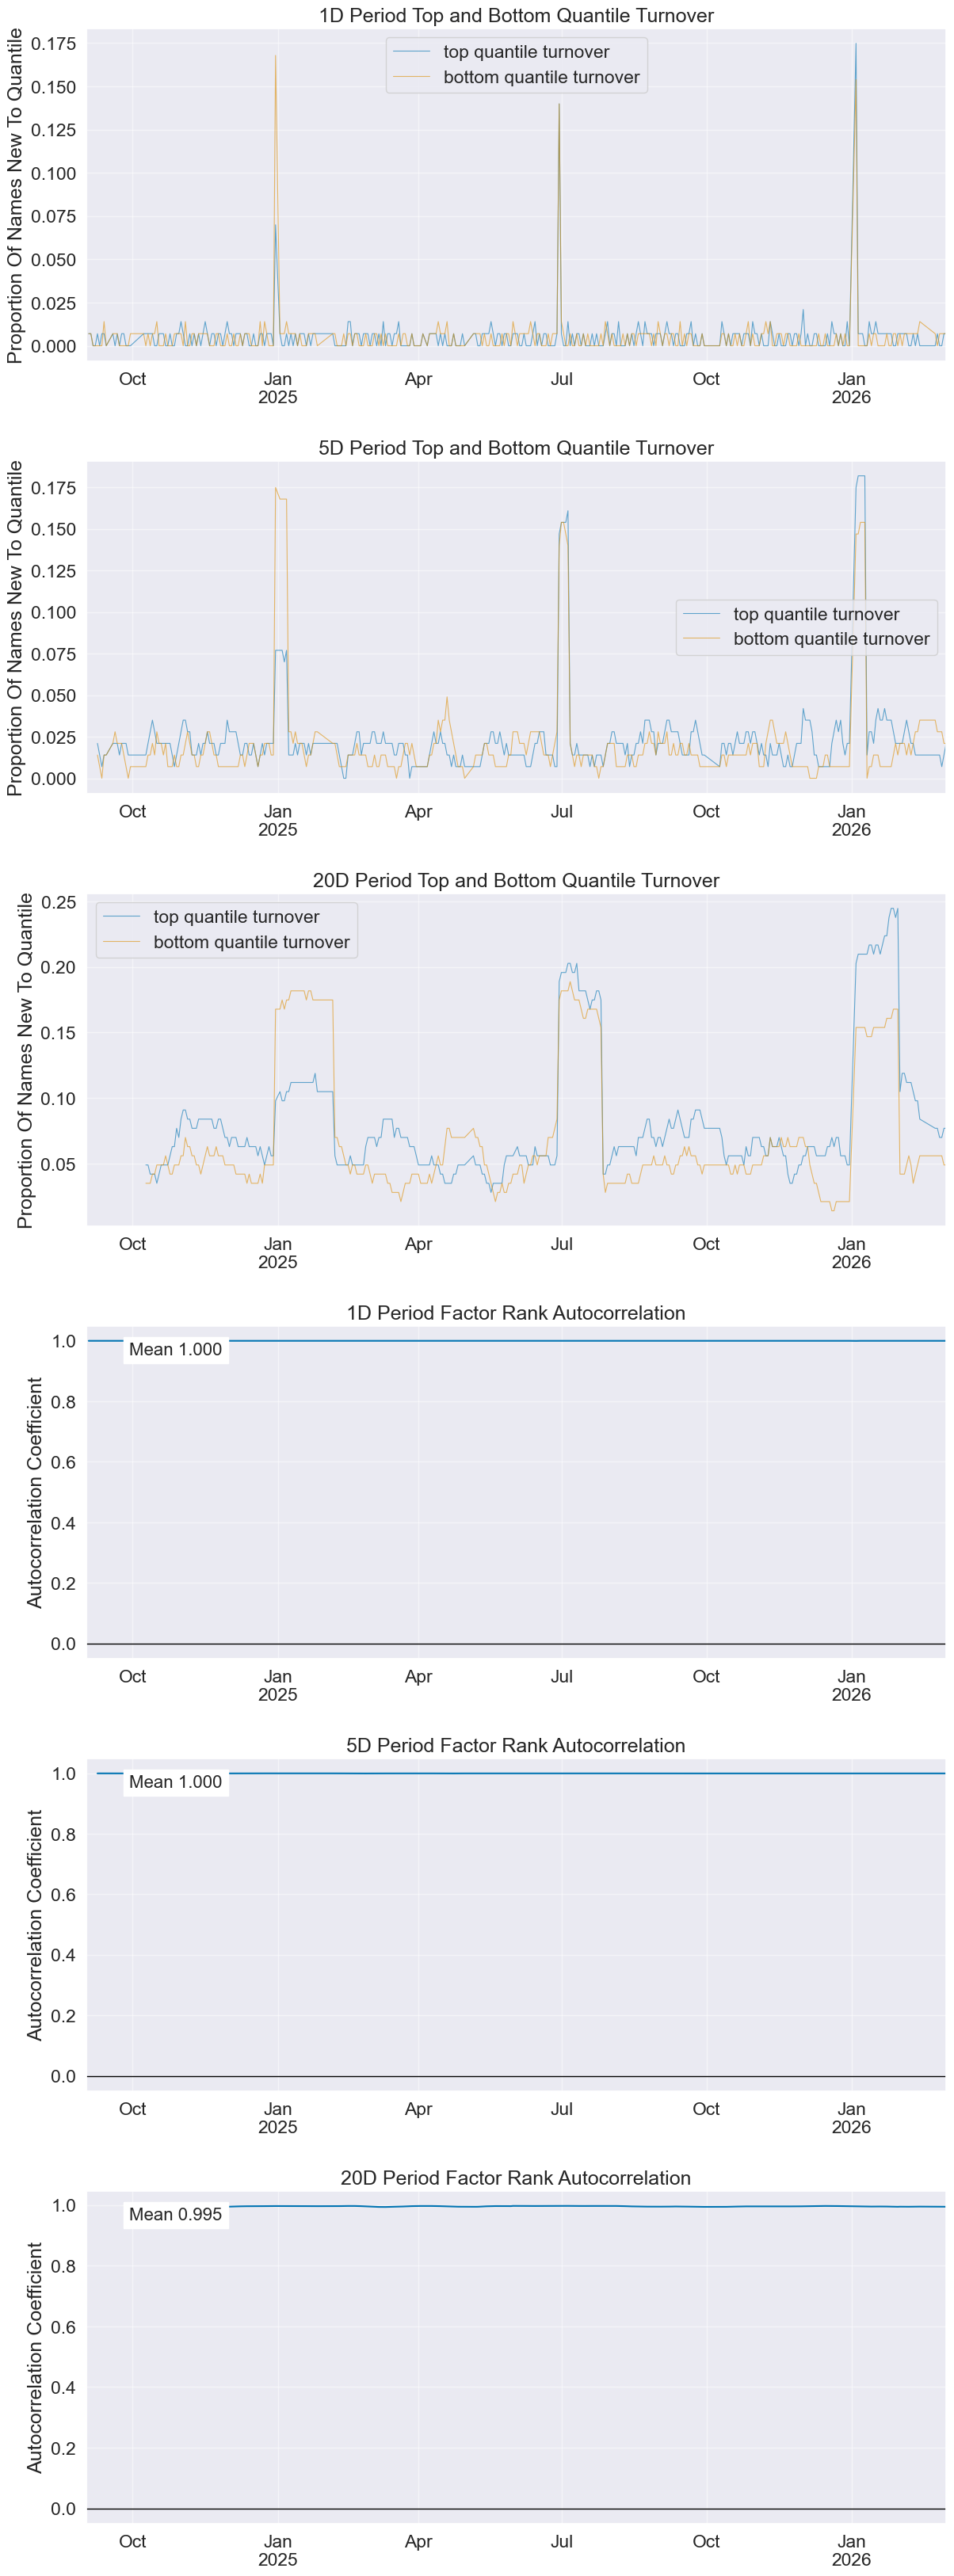

In [21]:
# 调用alphalens进行因子评估
al.tears.create_full_tear_sheet(
    factor_data=factor_data,
    long_short=True,
    group_neutral=False,
    by_group=False
)